In [ ]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

class1_sample.shape

(20, 3)

In [ ]:
df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

class2_sample.shape

(20, 3)

In [ ]:
df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

# df = df.append(df1,ignore_index=True)
df = pd.concat([df, df1], ignore_index=True)

df = df.sample(40)
df.shape

(40, 4)

In [ ]:
df

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
29,1.425140,1.441152,0.182561,0
31,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
32,-0.723253,1.461259,-0.085367,0
33,2.823378,-0.332863,2.637391,0


In [ ]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [ ]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
#The data is standardized to have mean  0 and variance 1. Values are near to 0 and 1 not exactly.

In [ ]:
df.describe()

,feature1,feature2,feature3,target
count,4.000000e+01,4.000000e+01,4.000000e+01,40.00000
mean,1.110223e-17,1.776357e-16,-9.992007e-17,0.50000
std,1.012739e+00,1.012739e+00,1.012739e+00,0.50637
min,-2.571350e+00,-1.998011e+00,-1.749156e+00,0.00000
25%,-6.772394e-01,-4.866010e-01,-6.815652e-01,0.00000
50%,-2.709371e-02,-3.531748e-02,2.798692e-02,0.50000
75%,7.181907e-01,5.677633e-01,4.687647e-01,1.00000
max,2.090049e+00,3.557281e+00,2.182786e+00,1.00000


In [ ]:
# Mean of each column
mean = df.mean()

# Variance of each column
variance = df.var()

print("Mean:\n", mean)
print("\nVariance:\n", variance)

Mean:
 feature1    2.220446e-17
feature2    2.386980e-16
feature3   -1.453915e-16
target      5.000000e-01
dtype: float64

Variance:
 feature1    1.025641
feature2    1.025641
feature3    1.025641
target      0.256410
dtype: float64


In [ ]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [ ]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [ ]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [ ]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

/tmp/ipykernel_6936/2391821092.py:18: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



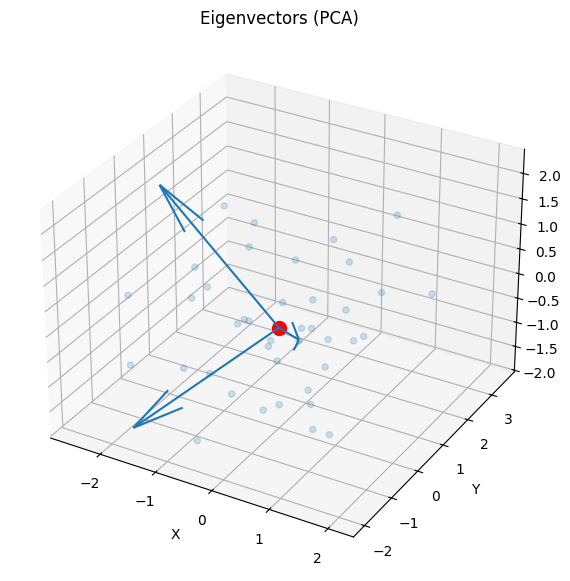

In [ ]:
# Vector Visualization

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(df['feature1'], df['feature2'], df['feature3'], alpha=0.2)

# Mean point
mean = df[['feature1','feature2','feature3']].mean()
ax.scatter(*mean, color='red', s=100)

# Eigenvectors
for v in eigen_vectors.T:
    ax.quiver(
        mean[0], mean[1], mean[2],   # origin
        v[0], v[1], v[2],            # direction
        length=3,                    # scale
        normalize=True
    )

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.title("Eigenvectors (PCA)")
plt.show()

In [ ]:
# Taking First 2 PC components:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [ ]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# [40,3] * [3,2] = [40,2] Matrix multiplication
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,0
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [ ]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()